# Моделирование распространения сигнала в аудитории 8507

### Импорты

In [29]:
import drjit as dr
import mitsuba as mi

# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, ITURadioMaterial, SceneObject

### Загрузка сцены

Файл `room.xml` изначально был создан в Blender 3.6. Сцена представляет собой кабинет, с двумя пространствами, отделенными друг от друга стеклянной перегородкой. 3D модель экспортирована с помощью плагина Mitsuba c кастомными настройками(вверх Z, вперед Y) По умолчанию загрузка сцены происходит с флагом `merge_shapes=True`, который объеденияет все объекты с одинаковыми радиоматериалами.

In [33]:
scene = load_scene("room.xml", merge_shapes=False)

Обработка файла, настройка отображения цвета, доопределение свойств материалов.

In [ ]:
import xml.etree.ElementTree as ET
import json


def update_material_colors(xml_path: str, config_path: str = "mat_colors.json"):
    with open(config_path, "r") as f:
        palette = json.load(f)
    
    tree = ET.parse(xml_path)
    for bsdf in tree.getroot().iter("bsdf"):
        if (mat_id := bsdf.get("id")) in palette:
            rgb_tag = bsdf.find("rgb")
            if rgb_tag is None:
                rgb_tag = ET.SubElement(bsdf, "rgb", name="reflectance")
            rgb_tag.set("value", palette[mat_id])
            
    tree.write(xml_path, xml_declaration=True, encoding="utf-8")

# 1. Применяем цвета к файлу
update_material_colors("room.xml")



tree = ET.parse("room.xml")
root = tree.getroot()

for shape in root.findall(".//shape"):
    filename_elem = shape.find("./string[@name='filename']")
    if filename_elem is not None:
        value = filename_elem.get("value")
        if value and value.endswith(".ply"):
            basename = os.path.basename(value)
            name_without_ext = os.path.splitext(basename)[0]
            # Обновляем и id, и name
            shape.set("id", name_without_ext)
            shape.set("name", name_without_ext)
            print(f"Обновлён shape: id='{name_without_ext}', name='{name_without_ext}'")
        else:
            print(f"Пропущен shape: value='{value}'")
    else:
        print(f"Пропущен shape (нет filename): {shape.attrib}")

tree.write("room.xml", xml_declaration=True, encoding="utf-8")
print("\nФайл room.xml успешно обновлён (id и name).")




# 2. ОБЯЗАТЕЛЬНО перезагружаем сцену (Sionna кэширует XML при первом чтении)
scene = load_scene("room.xml", merge_shapes=False)

# После загрузки сцены (scene = load_scene("room.xml"))
# Присваиваем радио-материалы и толщину

print("Доступные объекты в сцене:")
for name, obj in scene.objects.items():
    print(f"  {name} -> {obj}")

# Стены и пол — бетон (толщина стен 0.2 м, пол обычно бесконечной толщины, но можно задать 0.3)
wall = scene.get("wall")
wall.radio_material = "itu-concrete"
wall.thickness = 0.15  # толщина стены в метрах

floor = scene.get("floor")
floor.radio_material = "itu-concrete"
floor.thickness = 0.3  # толщина пола

# Стеклянная перегородка (толщина 0.01 м)
partition = scene.get("partition")
partition.radio_material = "itu-glass"
partition.thickness = 0.01

# Столы (дерево, толщина ~0.05 м)
table1 = scene.get("table1")
table1.radio_material = "itu-wood"
table1.thickness = 0.05

table2 = scene.get("table2")
table2.radio_material = "itu-wood"
table2.thickness = 0.05

table3 = scene.get("table3")
table3.radio_material = "itu-wood"
table3.thickness = 0.05

# Компьютеры (металл, толщина ~0.1 м)
comp1 = scene.get("comp1")
comp1.radio_material = "itu-metal"
comp1.thickness = 0.1

comp2 = scene.get("comp2")
comp2.radio_material = "itu-metal"
comp2.thickness = 0.1

comp3 = scene.get("comp3")
comp3.radio_material = "itu-metal"
comp3.thickness = 0.1

# Точки (point_001, point_002, point_003) — возможно, это мелкие объекты, например, маркеры или маленькие предметы.
# Если они имеют значение для отражения, можно задать им материал "itu-wood" или другой.
# Если это просто маркеры для позиционирования, они не должны влиять на радиоканал, но для полноты присвоим дерево с малой толщиной.
point1 = scene.get("point_001")
point1.radio_material = "itu-wood"
point1.thickness = 0.01

point2 = scene.get("point_002")
point2.radio_material = "itu-wood"
point2.thickness = 0.01

point3 = scene.get("point_003")
point3.radio_material = "itu-wood"
point3.thickness = 0.01

# Дополнительно: если какие-то объекты не должны участвовать в распространении (например, точки), 
# можно отключить их взаимодействие:
# point1.radio_material = None
# point2.radio_material = None
# point3.radio_material = None


Обновлён shape: id='wall', name='wall'
Обновлён shape: id='floor', name='floor'
Обновлён shape: id='partition', name='partition'
Обновлён shape: id='table2', name='table2'
Обновлён shape: id='table1', name='table1'
Обновлён shape: id='table3', name='table3'
Обновлён shape: id='comp1', name='comp1'
Обновлён shape: id='comp2', name='comp2'
Обновлён shape: id='comp3', name='comp3'
Обновлён shape: id='point_001', name='point_001'
Обновлён shape: id='point_002', name='point_002'
Обновлён shape: id='point_003', name='point_003'

Файл room.xml успешно обновлён (id и name).
Доступные объекты в сцене:
  wall -> <sionna.rt.scene_object.SceneObject object at 0x000001ECE37D3CD0>
  floor -> <sionna.rt.scene_object.SceneObject object at 0x000001ECCE85C650>
  partition -> <sionna.rt.scene_object.SceneObject object at 0x000001ECD26FFFD0>
  table2 -> <sionna.rt.scene_object.SceneObject object at 0x000001ECCFB9A1D0>
  table1 -> <sionna.rt.scene_object.SceneObject object at 0x000001ECD2654790>
  table3 -

Создание экземпляров камер,визуализация.

In [48]:
cam = Camera(position=[0,0,10],  look_at=[0,0,0])
cam_1 = Camera(position=[10,-5,12], look_at=[0,0,0])

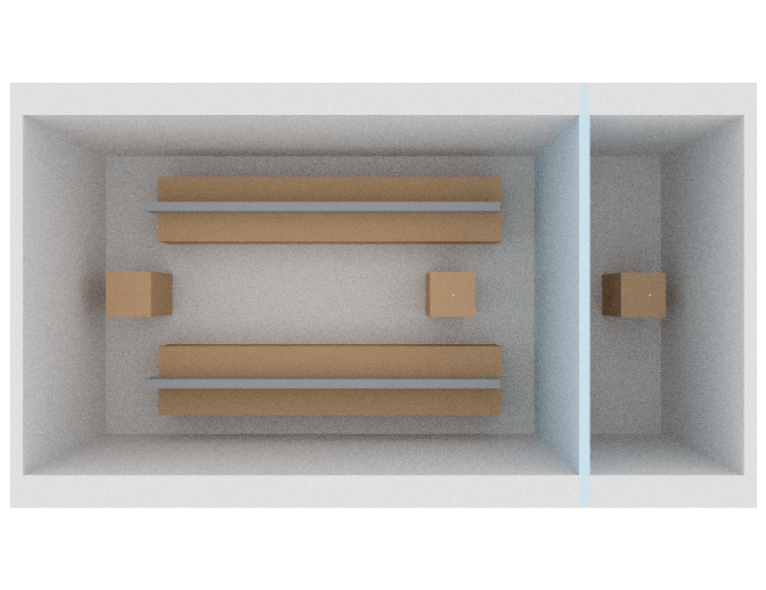

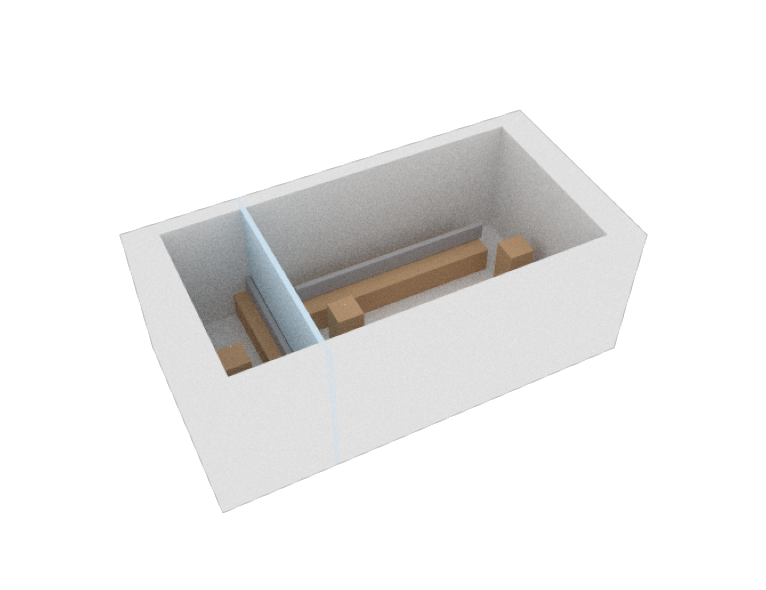

In [49]:
if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

if no_preview:
    scene.render(camera=cam_1);
else:
    scene.preview();

In [50]:
# Add a transmitter 
scene.remove("tx")
scene.add(Transmitter("tx", position=[0, 2.82, -0.486+0.6], display_radius=0.01))

# Add a receivers
scene.remove("rx-1")
scene.remove("rx-2")
rx_1 = [0,-2.92,-0.486+0.6]
rx_2 = [0,-0.766,-0.4853+0.6]

scene.add(Receiver(f"rx-1", position=rx_1, display_radius=0.01))
scene.add(Receiver(f"rx-2", position=rx_2, display_radius=0.01))

# Set the transmit and receive antenna arrays
scene.tx_array = PlanarArray(num_cols=1,
                             num_rows=1,
                             pattern="iso",
                             polarization="V")
scene.rx_array = scene.tx_array

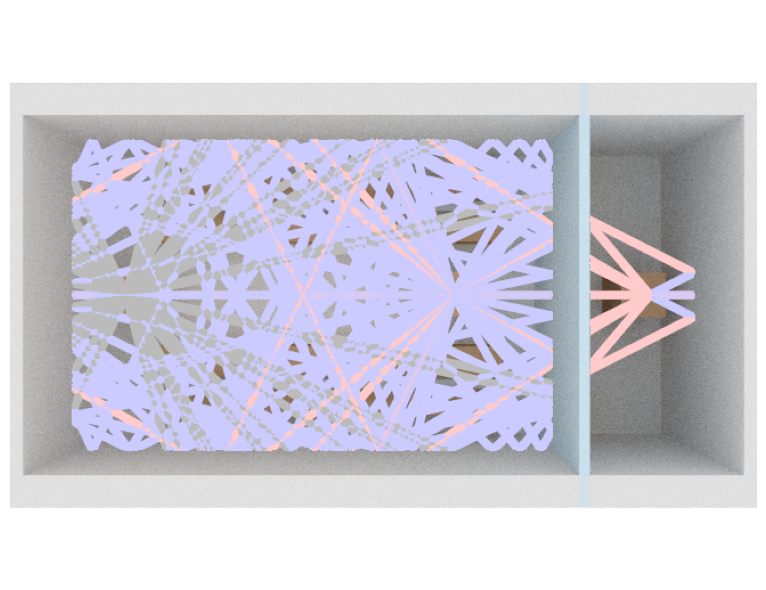

In [53]:
p_solver = PathSolver()
paths = p_solver(scene, max_depth=4)

if no_preview:
    scene.render(camera=cam, paths=paths);
else:
    scene.preview(paths=paths);

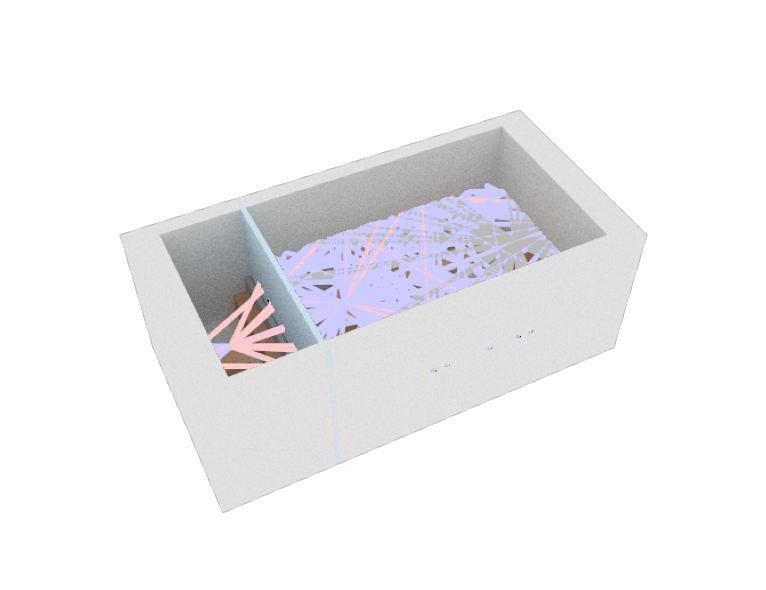

In [54]:
if no_preview:
    scene.render(camera=cam_1, paths=paths);
else:
    scene.preview(paths=paths);